In [1]:
import pandas as pd
from math import exp
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score
from sklearn.metrics import median_absolute_error
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
# pd.set_option('display.float_format', '{:,.4E}'.format)

In [4]:
data = pd.read_csv('data_FTS.csv')
data

,index,W,Ta,Tin,Tout,Pin,Pout,Fin,Fin.1,Fout,...,Fout.25,Fout.26,Fout.27,Fout.28,Fout.29,Fout.30,Fout.31,Fout.32,Fout.33,Fout.34
0,component names,NaN,NaN,NaN,NaN,NaN,NaN,hydrogen,carbon monoxide,hydrogen,...,pentacosane,1-heptene,1-octene,1-nonene,1-decene,1-undecene,1-dodecene,1-tridecene,1-tetradecene,1-pentadecene
1,unit,g,C,C,C,Pa,Pa,mol/s,mol/s,mol/s,...,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s
2,NaN,"5,12",230,230,233,"2247156,18",NaN,"1,22E-04","3,96E-05","1,02E-04",...,"4,76E-09","2,31E-08","2,41E-08","1,53E-08","1,17E-08","8,26E-09","5,44E-09","3,35E-09","2,11E-09","1,53E-09"
3,NaN,"5,12",230,230,233,"2240261,43",NaN,"1,22E-04","3,96E-05","1,03E-04",...,"4,53E-09","2,20E-08","2,29E-08","1,45E-08","1,11E-08","7,86E-09","5,18E-09","3,19E-09","2,01E-09","1,46E-09"
4,NaN,"5,12",230,230,233,"2233366,67",NaN,"1,22E-04","3,96E-05","1,02E-04",...,"4,64E-09","2,26E-08","2,35E-08","1,49E-08","1,14E-08","8,06E-09","5,31E-09","3,27E-09","2,06E-09","1,49E-09"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,NaN,"5,12",230,230,233,"2378156,57",NaN,"7,21E-05","3,48E-05","6,12E-05",...,"3,78E-09","1,84E-08","1,91E-08","1,21E-08","9,26E-09","6,56E-09","4,32E-09","2,66E-09","1,68E-09","1,22E-09"
67,NaN,"5,12",230,230,233,"2378156,57",NaN,"7,21E-05","3,48E-05","6,07E-05",...,"3,84E-09","1,87E-08","1,95E-08","1,23E-08","9,42E-09","6,67E-09","4,40E-09","2,71E-09","1,71E-09","1,24E-09"
68,NaN,"5,12",210,210,211,"2371261,81",NaN,"8,59E-05","4,71E-05","7,59E-05",...,"5,33E-09","2,59E-08","2,70E-08","1,71E-08","1,31E-08","9,25E-09","6,10E-09","3,76E-09","2,37E-09","1,72E-09"
69,NaN,"5,12",210,210,211,"2357472,30",NaN,"8,59E-05","4,71E-05","7,63E-05",...,"5,31E-09","2,58E-08","2,69E-08","1,70E-08","1,30E-08","9,22E-09","6,08E-09","3,74E-09","2,36E-09","1,71E-09"


In [5]:
component_list = parafins + olefins + others

In [6]:
olefins = ['ethylene',
 # 'propene',
 # '1-butene',
 # '1-pentene',
 # '1-hexene',
 '1-heptene',
 '1-octene',
 '1-nonene',
 '1-decene',
 '1-undecene',
 '1-dodecene',
 '1-tridecene',
 '1-tetradecene',
 '1-pentadecene']

In [7]:
parafins = ['methane',
 'ethane',
 'propane',
 # 'butane',
 # 'pentane',
 # 'hexane',
 'heptane',
 'octane',
 'nonane',
 'decane',
 'undecane',
 'dodecane',
 'tridecane',
 'tetradecane',
 'pentadecane',
 'hexadecane',
 'heptadecane',
 'octadecane',
 'nonadecane',
 'eicosane',
 'heneicosane',
 'docosane',
 'tricosane',
 'tetracosane',
 'pentacosane']

In [8]:
component_list = ['methane',
 'ethane',
 'propane',
 # 'butane',
 # 'pentane',
 # 'hexane',
 'heptane',
 'octane',
 'nonane',
 'decane',
 'undecane',
 'dodecane',
 'tridecane',
 'tetradecane',
 'pentadecane',
 'hexadecane',
 'heptadecane',
 'octadecane',
 'nonadecane',
 'eicosane',
 'heneicosane',
 'docosane',
 'tricosane',
 'tetracosane',
 'pentacosane',
 'ethylene',
 # 'propene',
 # '1-butene',
 # '1-pentene',
 # '1-hexene',
 '1-heptene',
 '1-octene',
 '1-nonene',
 '1-decene',
 '1-undecene',
 '1-dodecene',
 '1-tridecene',
 '1-tetradecene',
 '1-pentadecene',
 'carbon monoxide',
 'hydrogen',
 'water']

In [9]:
# filling index numbers
data = data.replace(to_replace=',', value='.', regex=True)
# if data not numeric: convert to numeric
# data.iloc[2:] = data.iloc[2:].apply(pd.to_numeric, axis=0)
for col_title in data.columns:
    component = data.loc[0, col_title]
    # if component not in component list, append it
    if 'Fin' in col_title:
        data = data.rename(columns = {col_title: f"Fin_{component}"})
        # if component not in component list, append it
        if component not in component_list:
            component_list.append(component)
    elif 'Fout' in col_title:
        data = data.rename(columns = {col_title: f"Fout_{component}"})
        if component not in component_list:
            component_list.append(component)

In [10]:
data.head()

,index,W,Ta,Tin,Tout,Pin,Pout,Fin_hydrogen,Fin_carbon monoxide,Fout_hydrogen,...,Fout_pentacosane,Fout_1-heptene,Fout_1-octene,Fout_1-nonene,Fout_1-decene,Fout_1-undecene,Fout_1-dodecene,Fout_1-tridecene,Fout_1-tetradecene,Fout_1-pentadecene
0,component names,NaN,NaN,NaN,NaN,NaN,NaN,hydrogen,carbon monoxide,hydrogen,...,pentacosane,1-heptene,1-octene,1-nonene,1-decene,1-undecene,1-dodecene,1-tridecene,1-tetradecene,1-pentadecene
1,unit,g,C,C,C,Pa,Pa,mol/s,mol/s,mol/s,...,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s,mol/s
2,NaN,5.12,230,230,233,2247156.18,NaN,1.22E-04,3.96E-05,1.02E-04,...,4.76E-09,2.31E-08,2.41E-08,1.53E-08,1.17E-08,8.26E-09,5.44E-09,3.35E-09,2.11E-09,1.53E-09
3,NaN,5.12,230,230,233,2240261.43,NaN,1.22E-04,3.96E-05,1.03E-04,...,4.53E-09,2.20E-08,2.29E-08,1.45E-08,1.11E-08,7.86E-09,5.18E-09,3.19E-09,2.01E-09,1.46E-09
4,NaN,5.12,230,230,233,2233366.67,NaN,1.22E-04,3.96E-05,1.02E-04,...,4.64E-09,2.26E-08,2.35E-08,1.49E-08,1.14E-08,8.06E-09,5.31E-09,3.27E-09,2.06E-09,1.49E-09


In [11]:
fout_cols = [col for col in data.columns if col.startswith('Fout')]

Fj_out = data.loc[2:, fout_cols].apply(pd.to_numeric)

Fout = Fj_out.sum(axis=1)
y_H2_out = Fj_out['Fout_hydrogen'] / Fout
y_CO_out = Fj_out['Fout_carbon monoxide'] / Fout

In [12]:
kinetic_data = pd.DataFrame()
kinetic_data['T_R_K'] = data.loc[2:, 'Tout'].astype('int32') + 273

In [13]:
F_CO_in = data.loc[2:, 'Fin_carbon monoxide'].astype('float')
F_CO_out = data.loc[2:, 'Fout_carbon monoxide'].astype('float')
W = data.loc[2:, 'W'].astype('float')

kinetic_data['-r_CO_exp'] = (F_CO_in - F_CO_out) / W

In [14]:
F_H2_in = data.loc[2:, 'Fin_hydrogen'].astype('float')
F_H2_out = data.loc[2:, 'Fout_hydrogen'].astype('float')
W = data.loc[2:, 'W'].astype('float')

kinetic_data['-r_H2_exp'] = (F_H2_in - F_H2_out) / W

In [15]:
Fj_out_products = Fj_out.drop(['Fout_hydrogen', 'Fout_carbon monoxide'], axis = 'columns')
rates_products_exp = Fj_out_products.divide(W, axis = 'rows')
rates_products_exp.columns = rates_products_exp.columns.str.removeprefix("Fout_")

In [16]:
n_parafins = {}
for i, parafin in enumerate(parafins):
    n = i + 1
    if n not in [4, 5, 6]:
        n_parafins[parafin] = n

In [17]:
n_olefins = {}
for i, olefin in enumerate(olefins):
    n = i + 2
    if n not in [3, 4, 5, 6]:
        n_olefins[olefin] = n

In [18]:
rates_exp_H2 = - kinetic_data['-r_H2_exp']
rates_exp_CO = - kinetic_data['-r_CO_exp']
rates_exp_H2O = data.loc[2:, 'Fout_water'].astype('float') / W

rates_exp_parafins = rates_products_exp[parafins]
rates_exp_parafins = rates_exp_parafins.rename(columns = n_parafins)
rates_exp_olefins = rates_products_exp[olefins]
rates_exp_olefins = rates_exp_olefins.rename(columns = n_olefins)

In [19]:
y_H2_in = F_H2_in / (F_H2_in + F_CO_in)
y_CO_in = F_CO_in / (F_H2_in + F_CO_in)

y_H2_mean = ( y_H2_in + y_H2_out ) / 2
y_CO_mean = ( y_CO_in + y_CO_out ) / 2

pressure = data.loc[2:, 'Pin'].astype('float')

kinetic_data['P_H2'] = (pressure * y_H2_mean).astype('float')
kinetic_data['P_CO'] = (pressure * y_CO_mean).astype('float')

In [20]:
N = [1, 2, 3, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
# N = list(range(1,50))

In [21]:
def sigmoid(x, L, x0, k, b):
    y = b + L / (1 + np.exp(-k*(x - x0)))
    return y

In [22]:
def y_n(T, H2_CO):
    L_K_C2, x0_K_C2, k_K_C2, b_K_C2 = [12.877, 495.969, -0.267, 1.942]
    L_K_C3, x0_K_C3, k_K_C3, b_K_C3 = [5.167, 496.098, -0.557, -0.366]
    K_C2 = sigmoid(T, L_K_C2, x0_K_C2, k_K_C2, b_K_C2)
    K_C3 = sigmoid(T, L_K_C3, x0_K_C3, k_K_C3, b_K_C3)

    alpha = 1 / ( 1 + np.exp( - ( 48.45 - 0.09191 * T - 0.7489 * H2_CO ) ) )

    y_n = {}

    for n in N:
        y_n[n] = ( 1 - alpha ) * alpha ** ( n - 1  + K_C2 * ( n == 2 ) + K_C3 * ( n == 3 ) )

    # the chategorical variables change the distribution sum to be always less than 1
    # so we will normalize it before returning
    y_n = {key: value/sum(y_n.values()) for key, value in y_n.items()}
    return y_n

In [23]:
def nu_n(n):
    exponential = np.exp ( - ( -3.303 + 0.4139 * n + 3.391 * ( n == 2 ) + 21.01 * ( n == 3 ) ) )
    nu_n = 1 / ( 1 + ( 1 - ( n == 1 ) ) * exponential )
    return nu_n

In [24]:
predicted_y_n = pd.DataFrame()

In [25]:
temperature = 273.15 + data.loc[2:, 'Tout'].astype(float)
H2_CO = ( F_H2_in / F_CO_in )

In [26]:
predicted_y_n = pd.DataFrame(y_n(temperature, H2_CO))

In [27]:
sum_n_yn = predicted_y_n.mul(predicted_y_n.columns, axis=1).sum(axis=1)

In [28]:
sum_yn_nu_n = predicted_y_n.mul(nu_n(predicted_y_n.columns), axis=1).sum(axis=1)

In [29]:
sum_yn_nu_n_2n = sum_yn_nu_n + 2 * sum_n_yn

In [30]:
kinetic_data['sum_n_yn'] = sum_n_yn
kinetic_data['sum_yn_nu_n_2n'] = sum_yn_nu_n_2n

In [31]:
# marking the df for train and test
# Source - https://stackoverflow.com/a
# Posted by Andy Hayden, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-28, License - CC BY-SA 3.0

np.random.seed(5)
kinetic_data['TRAIN'] = np.random.rand(len(kinetic_data)) < 0.7
trainning_data = kinetic_data.loc[kinetic_data.TRAIN == True]
test_data = kinetic_data.loc[kinetic_data.TRAIN == False]

In [61]:
def residuals(params, dataset, rate_fcn):
    r_CO_model = - rate_fcn(*params, dataset.T_R_K, dataset.P_CO, dataset.P_H2) * dataset['sum_n_yn']
    r_CO_exp = - dataset['-r_CO_exp']
    r_H2_model = - rate_fcn(*params, dataset.T_R_K, dataset.P_CO, dataset.P_H2) * dataset['sum_yn_nu_n_2n']
    r_H2_exp = - dataset['-r_H2_exp']
    res_CO = r_CO_exp - r_CO_model
    res_H2 = r_H2_exp - r_H2_model
    return res_CO, res_H2

In [33]:
def objective_fcn(params, train_data, rate_fcn):
    res_CO, res_H2 = residuals(params, train_data, rate_fcn)
    sum_diff_sqr = ( res_CO ** 2 + res_H2 ** 2 ).sum()
    return sum_diff_sqr

In [34]:
def update_pred_rate(rate_fcn, model_name, params):
    kinetic_data[f'-r_CO_{model_name}'] = rate_fcn(*params, 
                                                  kinetic_data.T_R_K, 
                                                  kinetic_data.P_CO, 
                                                  kinetic_data.P_H2) * kinetic_data['sum_n_yn']
    kinetic_data[f'-r_H2_{model_name}'] = rate_fcn(*params, 
                                                  kinetic_data.T_R_K, 
                                                  kinetic_data.P_CO, 
                                                  kinetic_data.P_H2) * kinetic_data['sum_yn_nu_n_2n']

In [35]:
def fit_function(train_data, rate_fcn, p0, bnds, model_name):
    sol = minimize(objective_fcn, p0,
             method='Nelder-Mead',
             bounds=bnds, 
             args = (train_data, rate_fcn),
             options = {'maxfev': None},
             )
    update_pred_rate(rate_fcn, model_name, sol.x)
    return sol

In [36]:
def rate_HCs_PowerLaw(A_HCs, E_HCs, a, b, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    rate = k_HCs * P_CO**a * P_H2**b
    return rate

p0_PowerLaw = [1, 1e5, 1, 1]
PowerLaw_bnds = ((0, None), (0, None), (0, None), (0, None))

sol_PowerLaw = fit_function(trainning_data, rate_HCs_PowerLaw, p0_PowerLaw, PowerLaw_bnds, 'PowerLaw')

In [37]:
def rate_HCs_Yates(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO * P_H2 / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Yates = [1, 5e4, 1, 1e5]
Yates_bnds = ( (0, None), (0, None), (0, None), (0, None) )

sol_Yates = fit_function(trainning_data, rate_HCs_Yates, p0_Yates, Yates_bnds, 'Yates')

In [38]:
def rate_HCs_Botes(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO**0.5 * P_H2**0.75 / ( ( 1 + K_CO * P_CO**0.5 ) ** 2 )
    return rate

p0_Botes = [1, 5e4, 1, 1e5]
Botes_bnds = ( (0, None), (0, None), (0, None), (0, None) )

sol_Botes = fit_function(trainning_data, rate_HCs_Botes, p0_Botes, Botes_bnds, 'Botes')

In [39]:
def rate_HCs_Ojeda(k_ads, H_ads, A_HCs_1, E_HCs_1, A_HCs_2, E_HCs_2, T, P_CO, P_H2):
    k_HCs_1 = A_HCs_1 * np.exp ( - E_HCs_1 / ( 8.314 * T ) )
    k_HCs_2 = A_HCs_2 * np.exp ( - E_HCs_2 / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = ( k_HCs_1 * P_H2 + k_HCs_2 ) * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Ojeda = [1, 5e4, 1, 1e5, 1, 1e5]
Ojeda_bnds = ( (0, None), (0, None), (0, None), (0, None), (0, None), (0, None) )

sol_Ojeda = fit_function(trainning_data, rate_HCs_Ojeda, p0_Ojeda, Ojeda_bnds, 'Ojeda')

In [40]:
def rate_HCs_Mousavi(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO * P_H2**0.75 / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Mousavi = [1, 5e4, 1, 1e5]
Mousavi_bnds = ( (0, None), (0, None), (0, None), (0, None) )

sol_Mousavi = fit_function(trainning_data, rate_HCs_Mousavi, p0_Mousavi, Mousavi_bnds, 'Mousavi')

In [41]:
def rate_HCs_PowerLaw2(k_ads, H_ads, A_HCs, E_HCs, a, b, c, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO**a * P_H2**b / ( ( 1 + K_CO * P_CO**c ) ** 2 )
    return rate

p0_PowerLaw2 = [1, 5e4, 1, 1e5, 1, 1, 1]
PowerLaw2_bnds = ( (0, None), (0, None), (0, None), (0, None), (None, None), (None, None), (None, None) )

sol_PowerLaw2 = fit_function(trainning_data, rate_HCs_PowerLaw2, p0_PowerLaw2, PowerLaw2_bnds, 'PowerLaw2')

In [42]:
def rates_n_parafin(kinetic_model, params, T, P_CO, P_H2, y_n, n_parafins):
    rates_n = {}
    for n in n_parafins.values():
        rates_n[n] = nu_n(n) * kinetic_model(*params, T, P_CO, P_H2)
    rates_n = pd.DataFrame(rates_n)
    rates_n = rates_n * y_n
    return rates_n

In [43]:
def rates_n_olefin(kinetic_model, params, T, P_CO, P_H2, y_n, n_olefins):
    rates_n = {}
    for n in n_olefins.values():
        rates_n[n] = ( 1 - nu_n(n) ) * kinetic_model(*params, T, P_CO, P_H2)
    rates_n = pd.DataFrame(rates_n)
    rates_n = rates_n * y_n
    return rates_n.dropna(axis = 'columns')

In [44]:
def predict_rates(rate_law, p0): 
    rates_pred_parafins = rates_n_parafin(rate_law, p0, 
                    kinetic_data.T_R_K, kinetic_data.P_CO, kinetic_data.P_H2,
                    predicted_y_n, n_parafins)
    
    rates_pred_olefins = rates_n_olefin(rate_law, p0, 
                    kinetic_data.T_R_K, kinetic_data.P_CO, kinetic_data.P_H2,
                    predicted_y_n, n_olefins)
    
    rates_pred_CO = -rates_pred_parafins.mul(rates_pred_parafins.columns, axis=1).sum(axis=1)
    rates_pred_CO += -rates_pred_olefins.mul(rates_pred_olefins.columns, axis=1).sum(axis=1)
    
    rates_pred_H2 = -rates_pred_parafins.mul(2 * rates_pred_parafins.columns + 1, axis=1).sum(axis=1)
    rates_pred_H2 += -rates_pred_olefins.mul(2 * rates_pred_olefins.columns + 1, axis=1).sum(axis=1)
    
    rates_pred_H2O = -rates_pred_CO
    return rates_pred_parafins, rates_pred_olefins, rates_pred_CO, rates_pred_H2, rates_pred_H2O

In [45]:
def remove_outliers(params_df):
    params_df = params_df.select_dtypes(include = 'number')
    Q1 = params_df.quantile(0.25)
    Q3 = params_df.quantile(0.75)
    IQR = Q3 - Q1
    
    params_df = params_df[~((params_df < (Q1 - 1.5 * IQR)) |(params_df > (Q3 + 1.5 * IQR))).any(axis=1)]
    return params_df

In [89]:
def plot_parity_rates(fig_name):
    fig, ax = plt.subplots(2,3,figsize=(10,6))
    plt.subplots_adjust(hspace=0.4, wspace = 0.3)
    plotting_data = remove_outliers(kinetic_data.loc[kinetic_data.TRAIN == False])
    max_xy = plotting_data['-r_H2_exp'].max()
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_CO_exp", 
                    y="-r_CO_PowerLaw", 
                    ax = ax[0,0],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_H2_exp", 
                    y="-r_H2_PowerLaw", 
                    ax = ax[0,0],
                    label = 'H2',
    )
    ax[0,0].plot((0, max_xy), (0, max_xy))
    ax[0,0].set_title('PowerLaw')
    ax[0,0].grid('both')
    ax[0,0].set_xlabel(r'$-r_{\mathrm{exp}}$ (mol/s/g)')
    ax[0,0].set_ylabel(r'$-r_{\mathrm{model}}$ (mol/s/g)')
    
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_CO_exp", 
                    y="-r_CO_Yates", 
                    ax = ax[0,1],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_H2_exp", 
                    y="-r_H2_Yates", 
                    ax = ax[0,1],
                    label = 'H2',
    )
    ax[0,1].plot((0, max_xy), (0, max_xy))
    ax[0,1].set_title('Yates')
    ax[0,1].grid('both')
    ax[0,1].set_xlabel(r'$-r_{\mathrm{exp}}$ (mol/s/g)')
    ax[0,1].set_ylabel(r'$-r_{\mathrm{model}}$ (mol/s/g)')
    
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_CO_exp", 
                    y="-r_CO_Botes", 
                    ax = ax[0,2],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_H2_exp", 
                    y="-r_H2_Botes", 
                    ax = ax[0,2],
                    label = 'H2',
    )
    ax[0,2].plot((0, max_xy), (0, max_xy))
    ax[0,2].set_title('Botes')
    ax[0,2].grid('both')
    ax[0,2].set_xlabel(r'$-r_{\mathrm{exp}}$ (mol/s/g)')
    ax[0,2].set_ylabel(r'$-r_{\mathrm{model}}$ (mol/s/g)')
    
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_CO_exp", 
                    y="-r_CO_Ojeda", 
                    ax = ax[1,0],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_H2_exp", 
                    y="-r_H2_Ojeda", 
                    ax = ax[1,0],
                    label = 'H2',
    )
    ax[1,0].plot((0, max_xy), (0, max_xy))
    ax[1,0].set_title('Ojeda')
    ax[1,0].grid('both')
    ax[1,0].set_xlabel(r'$-r_{\mathrm{exp}}$ (mol/s/g)')
    ax[1,0].set_ylabel(r'$-r_{\mathrm{model}}$ (mol/s/g)')
    
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_CO_exp", 
                    y="-r_CO_Mousavi", 
                    ax = ax[1,1],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_H2_exp", 
                    y="-r_H2_Mousavi", 
                    ax = ax[1,1],
                    label = 'H2',
    )
    ax[1,1].plot((0, max_xy), (0, max_xy))
    ax[1,1].set_title('Mousavi')
    ax[1,1].grid('both')
    ax[1,1].set_xlabel(r'$-r_{\mathrm{exp}}$ (mol/s/g)')
    ax[1,1].set_ylabel(r'$-r_{\mathrm{model}}$ (mol/s/g)')
    
    
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_CO_exp", 
                    y="-r_CO_PowerLaw2", 
                    ax = ax[1,2],
                    label = 'CO',
    )
    sns.scatterplot(
                    data=plotting_data, 
                    x="-r_H2_exp", 
                    y="-r_H2_PowerLaw2", 
                    ax = ax[1,2],
                    label = 'H2',
    )
    ax[1,2].plot((0, max_xy), (0, max_xy))
    ax[1,2].set_title('PowerLaw2')
    ax[1,2].grid('both')
    ax[1,2].set_xlabel(r'$-r_{\mathrm{exp}}$ (mol/s/g)')
    ax[1,2].set_ylabel(r'$-r_{\mathrm{model}}$ (mol/s/g)')

    plt.savefig(fig_name, bbox_inches = 'tight')


In [47]:
test_data = kinetic_data.loc[kinetic_data.TRAIN == False]

y_true = test_data[['-r_CO_exp', '-r_H2_exp']].melt().value

y_pred_PowerLaw = test_data[['-r_CO_PowerLaw', '-r_H2_PowerLaw']].melt().value
y_pred_Yates = test_data[['-r_CO_Yates', '-r_H2_Yates']].melt().value
y_pred_Botes = test_data[['-r_CO_Botes', '-r_H2_Botes']].melt().value
y_pred_Ojeda = test_data[['-r_CO_Ojeda', '-r_H2_Ojeda']].melt().value
y_pred_Mousavi = test_data[['-r_CO_Mousavi', '-r_H2_Mousavi']].melt().value
y_pred_PowerLaw2 = test_data[['-r_CO_PowerLaw2', '-r_H2_PowerLaw2']].melt().value

R2 = {
    'Model': ['PowerLaw', 'Yates', 'Botes', 'Ojeda', 'Mousavi', 'PowerLaw2'],
    'Median Absolute Error': [
        median_absolute_error(y_true, y_pred_PowerLaw),
        median_absolute_error(y_true, y_pred_Yates),
        median_absolute_error(y_true, y_pred_Botes),
        median_absolute_error(y_true, y_pred_Ojeda),
        median_absolute_error(y_true, y_pred_Mousavi),
        median_absolute_error(y_true, y_pred_PowerLaw2),
    ]
}
R2 = pd.DataFrame(R2)
R2

,Model,Median Absolute Error
0,PowerLaw,6.375554e-07
1,Yates,3.881970e-07
2,Botes,5.365134e-07
3,Ojeda,5.026519e-07
4,Mousavi,4.228243e-07
5,PowerLaw2,4.702707e-07


In [48]:
def calc_MAE(model_name):
    # test data must be updated from kinetic_data because kinetic data is updated during each fit
    test_data = kinetic_data.loc[kinetic_data.TRAIN == False]
    y_true = test_data[['-r_CO_exp', '-r_H2_exp']].melt().value
    y_pred = test_data[[f'-r_CO_{model_name}', f'-r_H2_{model_name}']].melt().value
    MAE = median_absolute_error(y_true, y_pred)
    return MAE

In [49]:
def solve_bootstrap(model_name, rate_fcn, p0, bnds, bootstrap_sample, bootstrap_results, i):
    print(f'Bootstrap iteration {i} for {model_name}')
    clear_output(wait=True)
    sol = fit_function(bootstrap_sample, rate_fcn, p0, bnds, model_name)
    MAE = calc_MAE(model_name)

    bootstrap_results['model'].append(model_name)
    bootstrap_results['iteration'].append(i)
    bootstrap_results['median_absolute_error'].append(MAE)
    bootstrap_results['params'].append(sol.x)
    bootstrap_results['success'].append(sol.success)
    bootstrap_results['nfev'].append(sol.nfev)
    bootstrap_results['message'].append(sol.message)

    return bootstrap_results

# bootstrapping
np.random.seed(None)

bootstrap_results = {'model': [], 'iteration': [], 'median_absolute_error': [], 'params': [],
                     'success': [], 'nfev': [], 'message': [],
                    }

for i in range(2):
    # generate a bootstrap sample of the same len as kinetic data from the trainning data
    sample_size = int(len(kinetic_data)/1)
    bootstrap_sample = trainning_data.sample(n = sample_size, replace = True)

    bootstrap_results = solve_bootstrap('PowerLaw', rate_HCs_PowerLaw, p0_PowerLaw, PowerLaw_bnds,
                                        bootstrap_sample, bootstrap_results, i)

    bootstrap_results = solve_bootstrap('Yates', rate_HCs_Yates, p0_Yates, Yates_bnds,
                                        bootstrap_sample, bootstrap_results, i)

    bootstrap_results = solve_bootstrap('Botes', rate_HCs_Botes, p0_Botes, Botes_bnds,
                                            bootstrap_sample, bootstrap_results, i)
    
    bootstrap_results = solve_bootstrap('Ojeda', rate_HCs_Ojeda, p0_Ojeda, Ojeda_bnds,
                                            bootstrap_sample, bootstrap_results, i)
    
    bootstrap_results = solve_bootstrap('PowerLaw2', rate_HCs_PowerLaw2, p0_PowerLaw2, PowerLaw2_bnds,
                                            bootstrap_sample, bootstrap_results, i)
    
    bootstrap_results = solve_bootstrap('Mousavi', rate_HCs_Mousavi, p0_Mousavi, Mousavi_bnds,
                                        bootstrap_sample, bootstrap_results, i)
    

bootstrap_results = pd.DataFrame(bootstrap_results)

bootstrap_results.to_pickle('bootstrap_results.pkl')

In [50]:
bootstrap_results = pd.read_pickle('bootstrap_results.pkl')

In [51]:
def build_params_df(bootstrap_model_results, params_names):
    params = bootstrap_model_results.params
    params = np.stack(params.values)
    params = pd.DataFrame(params, columns = params_names)
    return params

In [52]:
PowerLaw_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'PowerLaw'],
                               ('A_HCs', 'E_HCs', 'a', 'b'))

Yates_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Yates'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Botes_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Botes'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Ojeda_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Ojeda'],
                               ('k_ads', 'H_ads', 'A_HCs_1', 'E_HCs_1', 'A_HCs_2', 'E_HCs_2'))

Mousavi_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'Mousavi'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

PowerLaw2_params = build_params_df(bootstrap_results.loc[bootstrap_results.model == 'PowerLaw2'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs', 'a', 'b', 'c'))

In [91]:
def build_median_IQR_df(params_df):
    median = params_df.median()
    Q1 = params_df.quantile(0.25)
    Q3 = params_df.quantile(0.75)
    return pd.DataFrame((Q1, median, Q3), index = ['1st quartile', 'median', '3rd quartile'])

In [92]:
PowerLaw_median_IQR = build_median_IQR_df(PowerLaw_params)
Yates_median_IQR = build_median_IQR_df(Yates_params)
Botes_median_IQR = build_median_IQR_df(Botes_params)
Ojeda_median_IQR = build_median_IQR_df(Ojeda_params)
Mousavi_median_IQR = build_median_IQR_df(Mousavi_params)
PowerLaw2_median_IQR = build_median_IQR_df(PowerLaw2_params)

In [93]:
update_pred_rate(rate_HCs_PowerLaw, 'PowerLaw', PowerLaw_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Yates, 'Yates', Yates_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Botes, 'Botes', Botes_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Ojeda, 'Ojeda', Ojeda_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_Mousavi, 'Mousavi', Mousavi_median_IQR.loc['median'].values)
update_pred_rate(rate_HCs_PowerLaw2, 'PowerLaw2', PowerLaw2_median_IQR.loc['median'].values)

In [94]:
# test data must be updated from kinetic_data because kinetic data is updated during each fit
test_data = kinetic_data.loc[kinetic_data.TRAIN == False]

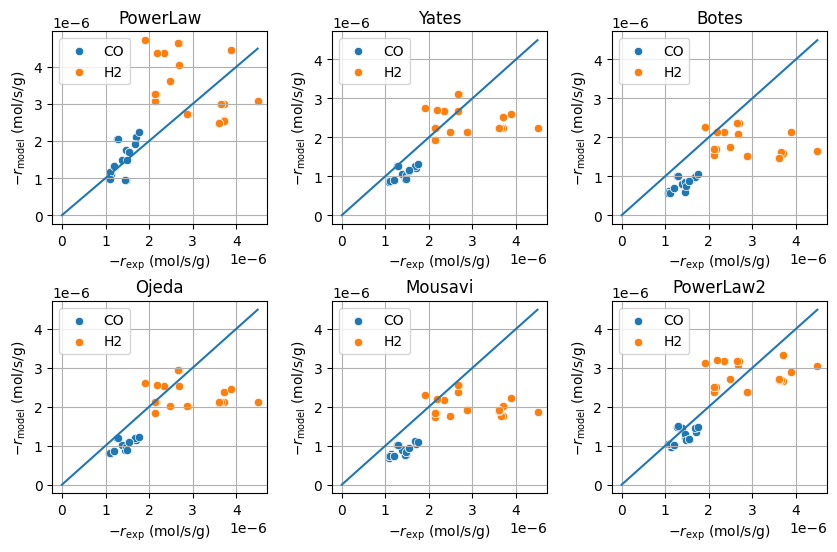

In [95]:
plot_parity_rates('bootstrap_parity.pdf')

In [96]:
PowerLaw2_median_IQR

,k_ads,H_ads,A_HCs,E_HCs,a,b,c
1st quartile,0.000006,4253.023535,1.552449e-07,117594.614727,1.188331,1.272976,1.348263
median,0.000021,10162.578793,1.396238e-03,144867.341099,1.502047,1.350603,1.457640
3rd quartile,0.000081,18468.406105,2.128687e-01,162885.520434,1.817076,1.481094,1.513857


In [97]:
Yates_median_IQR

,k_ads,H_ads,A_HCs,E_HCs
1st quartile,0.000311,0.000000,7.481808,134087.875242
median,0.000640,26.785148,18.457708,138870.169350
3rd quartile,0.001207,1032.012518,39.672120,144292.718239


In [98]:
def AICc(residuals, data, params):
    neg_logLik = -norm.logpdf(residuals,
                                np.mean(residuals),
                                np.std(residuals)).sum()

    # calculate AIC (AIC_c = AIC for small sample size)
    K = len(params) + 1
    N = len(data)
    aic   = 2*K + 2*neg_logLik
    aic_c = aic + (2*K**2 + 2*K)/(N - K - 1)
    return aic_c

In [99]:
residuals_PowerLaw = np.array(residuals(PowerLaw_median_IQR.loc['median'].values, test_data, rate_HCs_PowerLaw)).flatten()
residuals_Yates = np.array(residuals(Yates_median_IQR.loc['median'].values, test_data, rate_HCs_Yates)).flatten()
residuals_Botes = np.array(residuals(Botes_median_IQR.loc['median'].values, test_data, rate_HCs_Botes)).flatten()
residuals_Ojeda = np.array(residuals(Ojeda_median_IQR.loc['median'].values, test_data, rate_HCs_Ojeda)).flatten()
residuals_Mousavi = np.array(residuals(Mousavi_median_IQR.loc['median'].values, test_data, rate_HCs_Mousavi)).flatten()
residuals_PowerLaw2 = np.array(residuals(PowerLaw2_median_IQR.loc['median'].values, test_data, rate_HCs_PowerLaw2)).flatten()

In [100]:
stats_post_bootstrap = {
    'Model': ['PowerLaw', 'Yates', 'Botes', 'Ojeda', 'Mousavi', 'PowerLaw2'],
    'MAE': [
        calc_MAE('PowerLaw'),
        calc_MAE('Yates'),
        calc_MAE('Botes'),
        calc_MAE('Ojeda'),
        calc_MAE('Mousavi'),
        calc_MAE('PowerLaw2'),
    ],
    'AICc': [
        AICc(residuals_PowerLaw, test_data, PowerLaw_median_IQR.loc['median'].values),
        AICc(residuals_Yates, test_data, Yates_median_IQR.loc['median'].values),
        AICc(residuals_Botes, test_data, Botes_median_IQR.loc['median'].values),
        AICc(residuals_Ojeda, test_data, Ojeda_median_IQR.loc['median'].values),
        AICc(residuals_Mousavi, test_data, Mousavi_median_IQR.loc['median'].values),
        AICc(residuals_PowerLaw2, test_data, PowerLaw2_median_IQR.loc['median'].values),
    ],
}
stats_post_bootstrap = pd.DataFrame(stats_post_bootstrap)
stats_post_bootstrap.sort_values(by = 'AICc')

,Model,MAE,AICc
1,Yates,4.301460e-07,-1051.352059
4,Mousavi,5.769304e-07,-1049.514908
2,Botes,6.486319e-07,-1043.734787
3,Ojeda,4.578968e-07,-1042.251060
5,PowerLaw2,3.557819e-07,-1037.371351
0,PowerLaw,5.482499e-07,-1027.243683


In [101]:
print(stats_post_bootstrap.to_latex(index=False, 
                              formatters = {'Model': None, 'MAE': "{:.2E}", 'AICc': "{:.0f}"},
                             ))

\begin{tabular}{lrr}
\toprule
Model & MAE & AICc \\
\midrule
PowerLaw & 5.48E-07 & -1027 \\
Yates & 4.30E-07 & -1051 \\
Botes & 6.49E-07 & -1044 \\
Ojeda & 4.58E-07 & -1042 \\
Mousavi & 5.77E-07 & -1050 \\
PowerLaw2 & 3.56E-07 & -1037 \\
\bottomrule
\end{tabular}



In [108]:
print(Yates_median_IQR.to_latex(index=True, 
                              formatters = {'k_ads': "{:.2E}",
                                            'H_ads': "{:.0f}",
                                            'A_HCs': "{:.2f}",
                                            'E_HCs': "{:.0f}",
                                           }
                             ))

\begin{tabular}{lrrrr}
\toprule
 & k_ads & H_ads & A_HCs & E_HCs \\
\midrule
1st quartile & 3.11E-04 & 0 & 7.48 & 134088 \\
median & 6.40E-04 & 27 & 18.46 & 138870 \\
3rd quartile & 1.21E-03 & 1032 & 39.67 & 144293 \\
\bottomrule
\end{tabular}



In [109]:
print(Mousavi_median_IQR.to_latex(index=True, 
                              formatters = {'k_ads': "{:.2E}",
                                            'H_ads': "{:.0f}",
                                            'A_HCs': "{:.2f}",
                                            'E_HCs': "{:.0f}",
                                           }
                             ))

\begin{tabular}{lrrrr}
\toprule
 & k_ads & H_ads & A_HCs & E_HCs \\
\midrule
1st quartile & 6.84E-05 & 0 & 4.68 & 132244 \\
median & 1.48E-04 & 125 & 18.12 & 137108 \\
3rd quartile & 3.31E-04 & 1758 & 57.14 & 143744 \\
\bottomrule
\end{tabular}

